# Calculate and store membrane properties from 80 different membrane compositions
In this notebook we calculate and store the membrane properties from 80 different membrane compositions containg in total 10 unique lipid types. Each composition contains only 2 lipid types at most for simplicity.
Calculated membrane properties:
1. lipid packing (area per lipid)
2. average membrane Thickness
3. standard deviation of the membrane thickness
4. membrane compressability
5. bending modulus (not used in further analysis)
6. mean persistance between lipids
7. mean diffusivity of lipids
8. variation of voronoi area

In [1]:
%load_ext autoreload
import sys
import os
from pathlib import Path

import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm

sys.path.insert(1, '../../functions')
from lipid_gnn.functions_emil.functions import mkdir, pkl_load, pkl_save
import lipid_gnn.functions_emil.calculate_properties as calculate_properties

# Definition

In [2]:
data_folder = f'/home/phillip/Goethe/Thesis/lipid-graph-nn/data/membrane_only'
membrane_compositions = os.listdir(f'{data_folder}')
results_folder_path = Path(f"/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties")

In [3]:
len(os.listdir(data_folder))

70

# Calculate membrane properties

## Setup

In [8]:
%autoreload

# Definitions 
lag_persistence = 50
lag_diffusivity = 10
skip = True

## Calculation

In [11]:
for membrane_composition in tqdm(membrane_compositions):
    prop_result_file_path = str(results_folder_path / f"{membrane_composition}.h5")
    if os.path.isfile(prop_result_file_path) and skip:
        continue
    
    # load trajectory, discard equilibration phase and cut after 1 µs simulation time
    folder = f'{data_folder}/{membrane_composition}/run'
    trajectory = md.load(f'{folder}/prun.xtc', top=f'{folder}/prun.gro')[50:667]  
    
    # box xy value
    topology = open(f'{folder}/prun.gro').read()
    x = float(topology.split()[-3])
    y = float(topology.split()[-2])
    box_xy = [x, y]

    # calculate properties
    mean_dict, raw_dict = calculate_properties.compute_properties(trajectory,
                                                    box_xy = box_xy,
                                                    lag_persistence=lag_persistence,
                                                    lag_diffusivity=lag_diffusivity,
                                                    verbose=False)
    
    pkl_save(prop_result_file_path, [mean_dict, raw_dict])

100%|██████████| 70/70 [00:00<00:00, 35596.66it/s]


## Validation and tests

In [12]:
mean_dict, raw_dict = pkl_load(f'{results_folder_path}/POPC100.h5')
dt = 1.5 # ns

In [13]:
# print properties
print(f'lipid packing   : {mean_dict["lipid_packing"]:5.3f} [lipids / nm^2]')
print(f'thickness       : {mean_dict["thickness"]:5.2f} [A]')
print(f'thickness std   : {mean_dict["thickness_std"]:5.2f} [A] (frame-wise)')
print(f'compressibility : {mean_dict["compressibility"]:5.3f} [A^3 / kT]')
print(f'bending modulus : {mean_dict["bending_modulus"]:5.2f} [kT / A^3] (related to stiffness)')
print(f'mean persistence: {mean_dict["persistence"]:5.3f} (after lag of {lag_persistence} frames)')
print(f'mean diffusivity: {mean_dict["diffusivity"]:5.1f} [A^2] (after lag of {lag_diffusivity} frames)')
print(f'coeff. variation: {mean_dict["variation"]:5.3f} [A^2] (of Voronoi cell areas)')

lipid packing   : 3.015 [lipids / nm^2]
thickness       : 38.88 [A]
thickness std   :  2.15 [A] (frame-wise)
compressibility : 4.886 [A^3 / kT]
bending modulus : 151.94 [kT / A^3] (related to stiffness)
mean persistence: 0.078 (after lag of 50 frames)
mean diffusivity: 757.4 [A^2] (after lag of 10 frames)
coeff. variation: 0.257 [A^2] (of Voronoi cell areas)


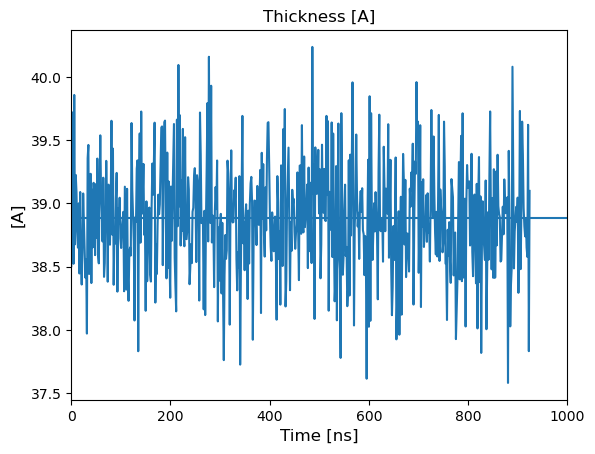

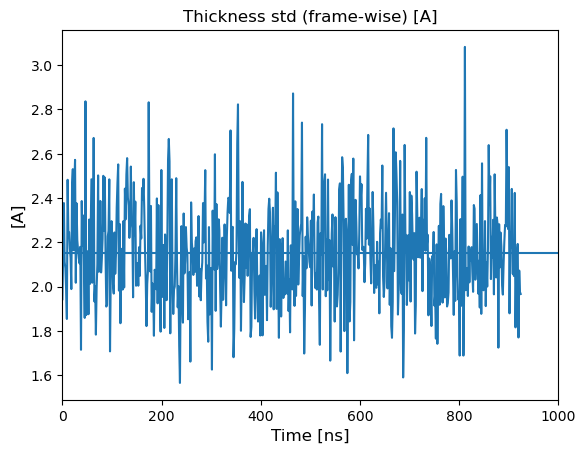

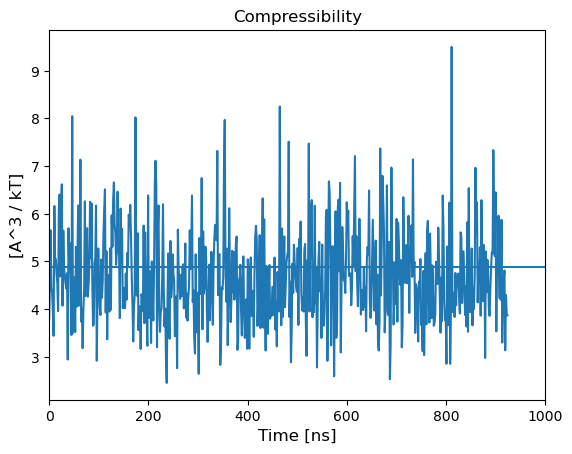

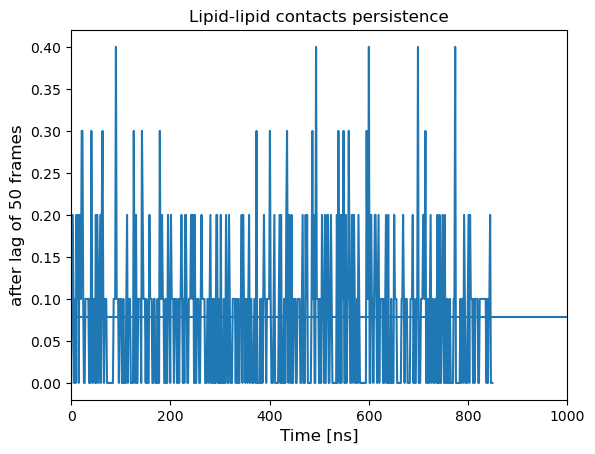

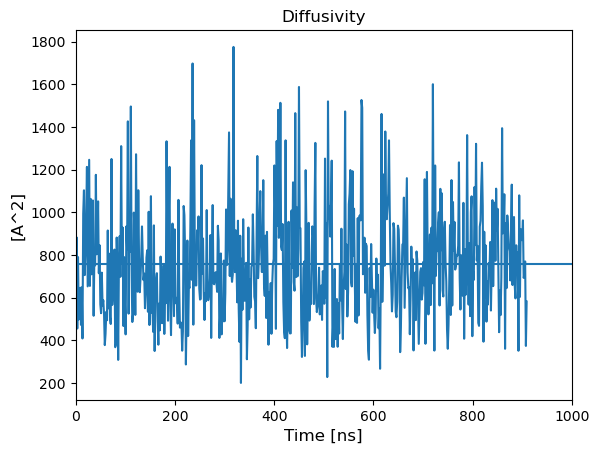

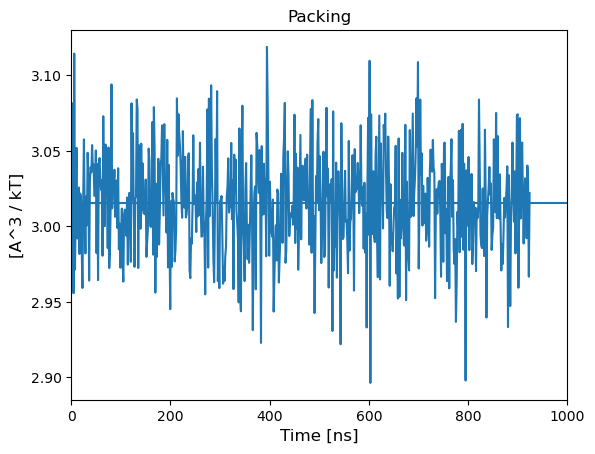

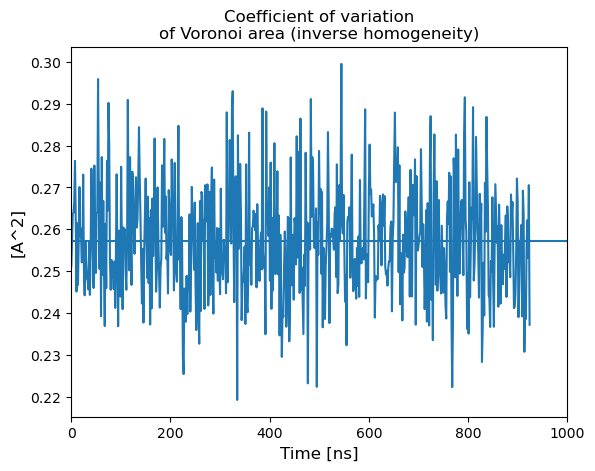

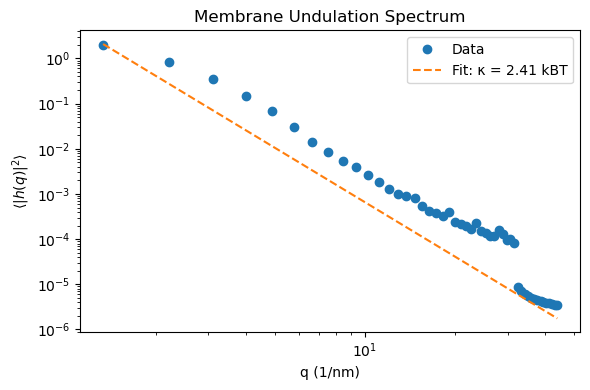

In [14]:
%autoreload
# plot Thickness
plt.figure()
plt.title('Thickness [A]')
plt.plot(np.arange(len(raw_dict['thickness']))*dt, raw_dict['thickness'])
plt.axhline(mean_dict['thickness'])
plt.ylabel('[A]', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Thickness_std
plt.figure()
plt.title('Thickness std (frame-wise) [A]')
plt.plot(np.arange(len(raw_dict['thickness_std']))*dt, raw_dict['thickness_std'])
plt.axhline(mean_dict['thickness_std'])
plt.ylabel('[A]', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Compressibility
plt.figure()
plt.title('Compressibility')
plt.plot(np.arange(len(raw_dict['compressibility']))*dt, raw_dict['compressibility'])
plt.axhline(mean_dict['compressibility'])
plt.ylabel('[A^3 / kT]', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Lipid-lipid contacts persistence
plt.figure()
plt.title('Lipid-lipid contacts persistence')
plt.plot(np.arange(len(raw_dict['persistence']))*dt, raw_dict['persistence'])
plt.axhline(mean_dict['persistence'])
plt.ylabel(f'after lag of {lag_persistence} frames', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Diffusivity
plt.figure()
plt.title('Diffusivity')
plt.plot(np.arange(len(raw_dict['diffusivity']))*dt, raw_dict['diffusivity'])
plt.axhline(mean_dict['diffusivity'])
plt.ylabel('[A^2]', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Lipid packing
plt.figure()
plt.title('Packing')
plt.plot(np.arange(len(raw_dict['lipid_packing']))*dt, raw_dict['lipid_packing'])
plt.axhline(mean_dict['lipid_packing'])
plt.ylabel('[A^3 / kT]', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Coefficient of variation\nof Voronoi area (inverse homogeneity)
plt.figure()
plt.title('Coefficient of variation\nof Voronoi area (inverse homogeneity)')
plt.plot(np.arange(len(raw_dict['variation']))*dt, raw_dict['variation'])
plt.axhline(mean_dict['variation'])
plt.ylabel('[A^2]', fontsize=12)
plt.xlabel('Time [ns]', fontsize=12)
plt.xlim(0, 1000)

# plot Membrane Undulation Spectrum
kBT = 2.5
popt, _ = curve_fit(calculate_properties.undulation_model, raw_dict['bending_modulus'][0], raw_dict['bending_modulus'][1])

plt.figure(figsize=(6, 4))
plt.loglog(raw_dict['bending_modulus'][0], raw_dict['bending_modulus'][1], 'o', label="Data")
plt.loglog(raw_dict['bending_modulus'][0], calculate_properties.undulation_model(raw_dict['bending_modulus'][0], *popt), '--',
           label=f"Fit: κ = {popt[0]:.2f} kBT")
plt.xlabel("q (1/nm)")
plt.ylabel(r"$\langle |h(q)|^2 \rangle$")
plt.title("Membrane Undulation Spectrum")
plt.legend()
plt.tight_layout()
plt.show()

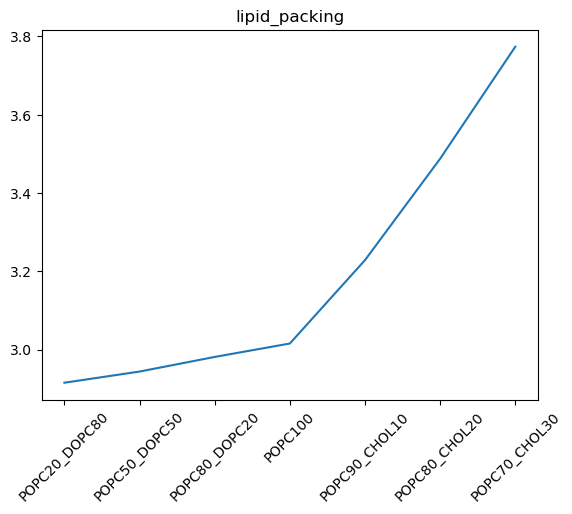

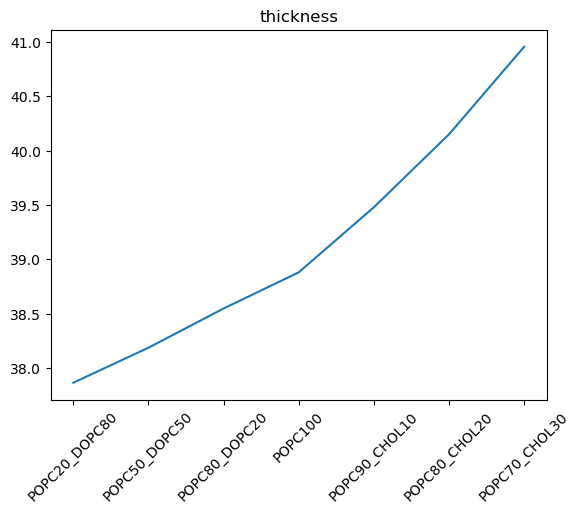

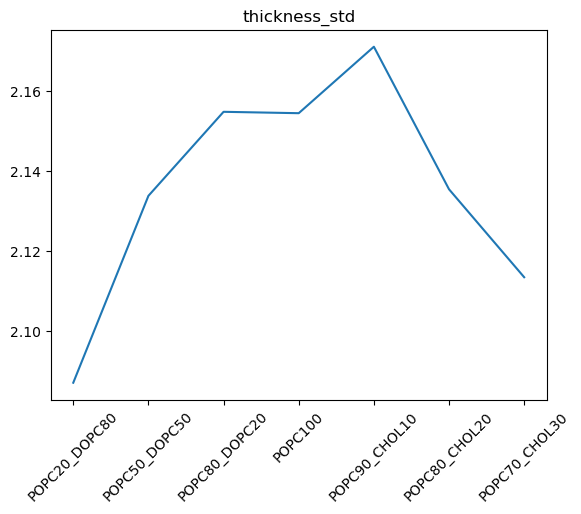

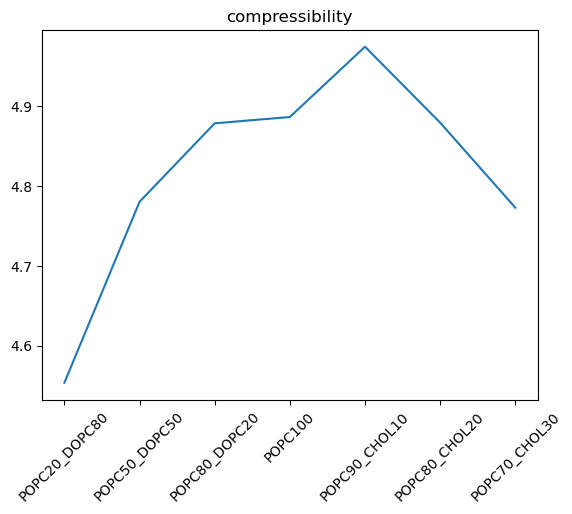

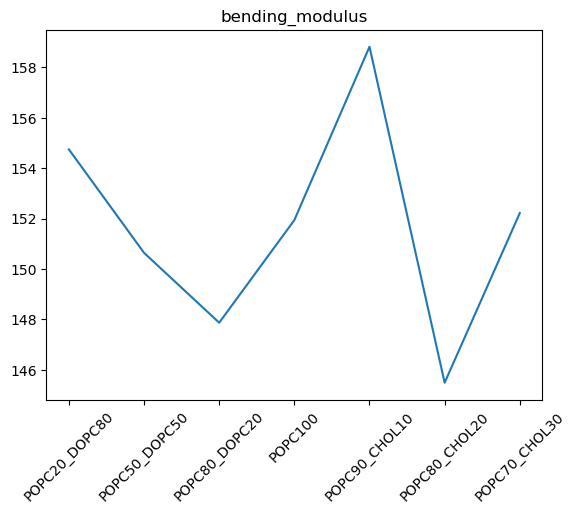

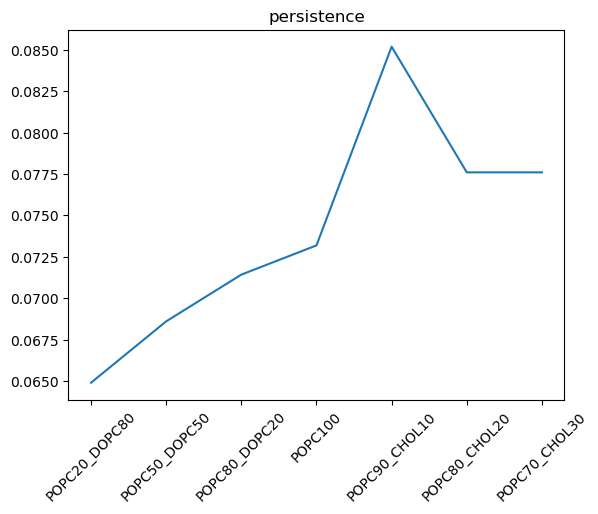

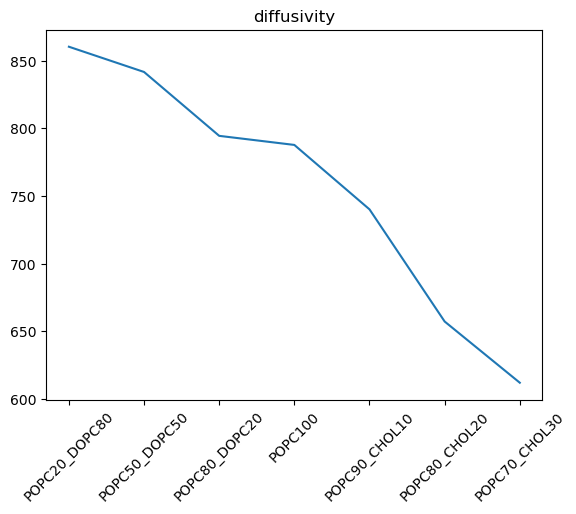

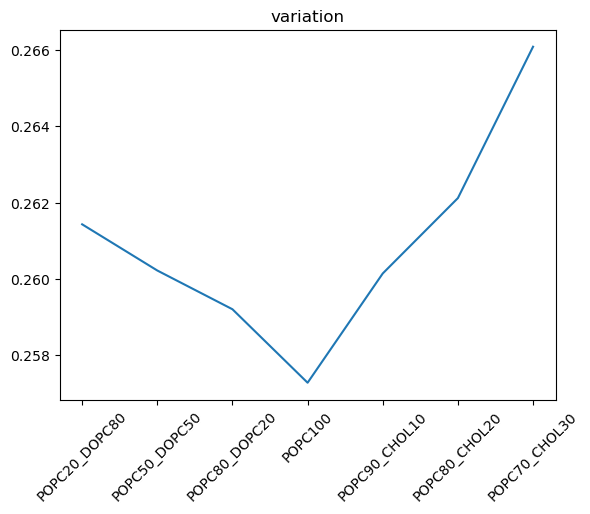

In [32]:
# Definitions
longest_membrane_comps = [
    'POPC20_DOPC80',
    'POPC50_DOPC50',
    'POPC80_DOPC20',
    'POPC100',
    'POPC90_CHOL10',
    'POPC80_CHOL20',
    'POPC70_CHOL30']

# setup
temp_dict = {}
for composition in pkl_load(f'{data_folder}/properties/POPC100.h5')[0]:
    temp_dict[composition] = []

# reorder
for composition in longest_membrane_comps:
    membrane_properties = pkl_load(f'{data_folder}/properties/{composition}.h5')[0]
    for membrane_property in membrane_properties:
        temp_dict[membrane_property].append(membrane_properties[membrane_property])
        
# plot
for i in temp_dict:
    plt.plot(temp_dict[i])
    plt.title(i)
    plt.xticks(np.arange(len(temp_dict[i])), labels=longest_membrane_comps, rotation=45)
    plt.show()